In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

os.listdir()

['.config', 'marketing_campaign.csv', 'marketing_campaign.xlsx', 'sample_data']

In [5]:
df = pd.read_csv("marketing_campaign.csv", sep=";")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [8]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [9]:
df.isnull().sum()


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [10]:
df.duplicated().sum()

np.int64(0)

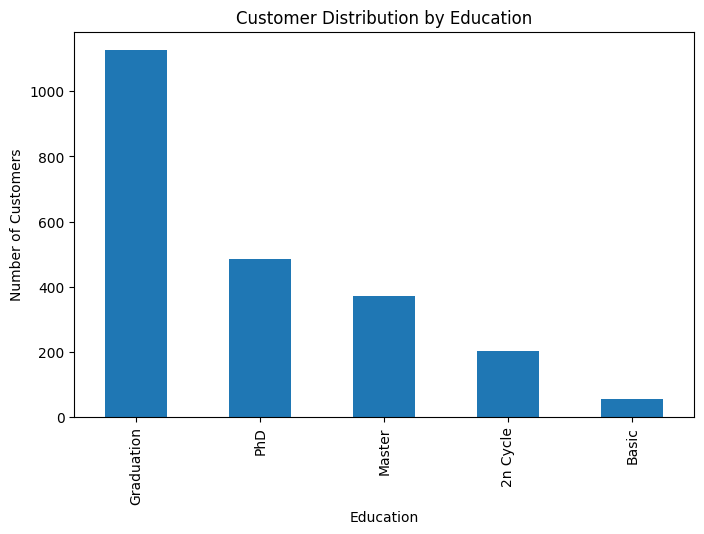

In [11]:
plt.figure(figsize=(8,5))
df["Education"].value_counts().plot(kind="bar")
plt.title("Customer Distribution by Education")
plt.xlabel("Education")
plt.ylabel("Number of Customers")
plt.show()

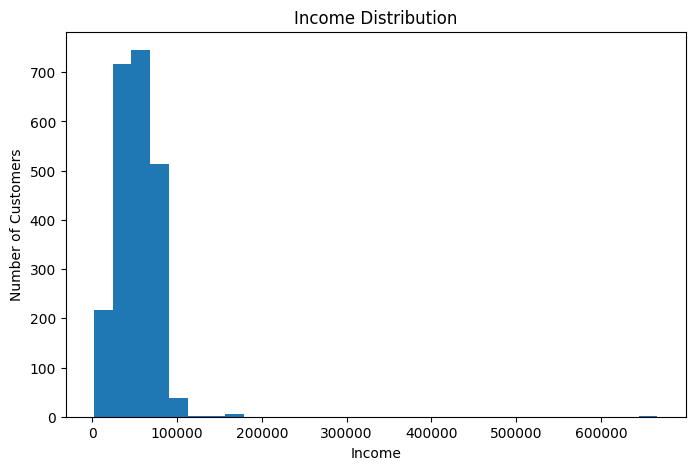

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["Income"], bins=30)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.show()

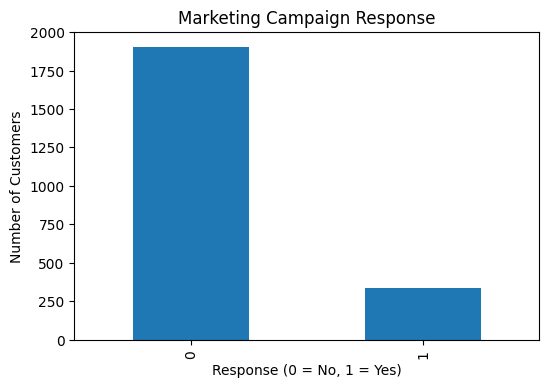

In [13]:
plt.figure(figsize=(6,4))
df["Response"].value_counts().plot(kind="bar")
plt.title("Marketing Campaign Response")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

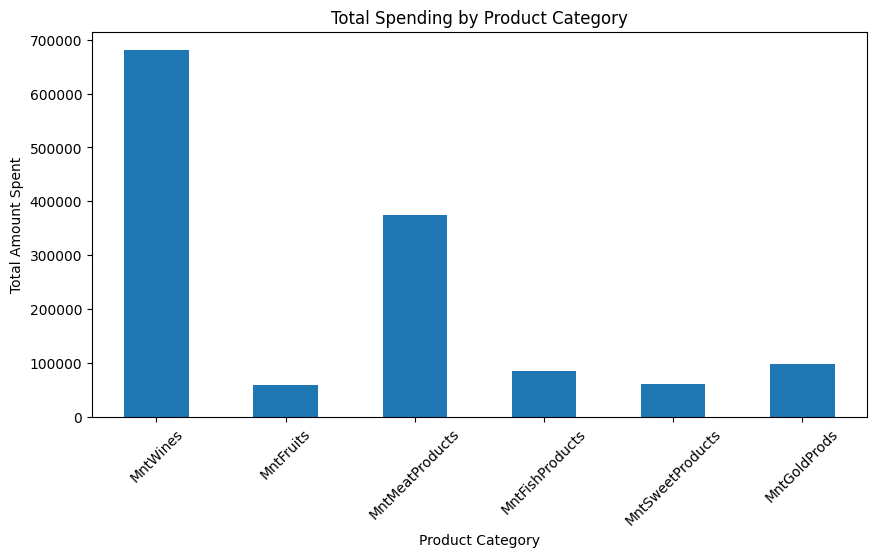

In [14]:
product_sales = df[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]].sum()

plt.figure(figsize=(10,5))
product_sales.plot(kind="bar")
plt.title("Total Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Amount Spent")
plt.xticks(rotation=45)
plt.show()

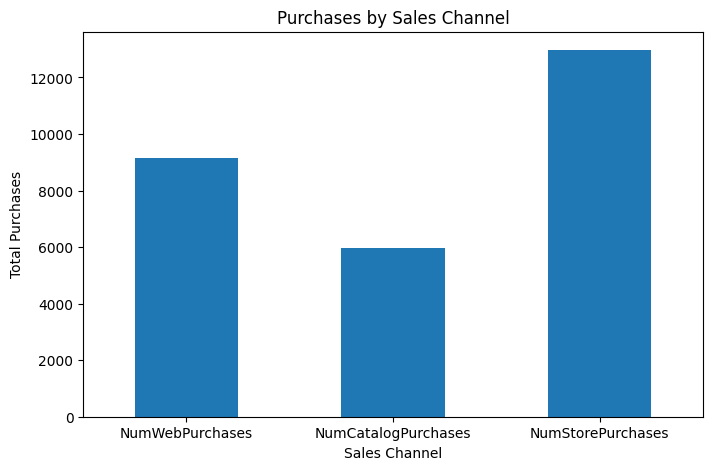

In [15]:
purchase_channels = df[[
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]].sum()

plt.figure(figsize=(8,5))
purchase_channels.plot(kind="bar")
plt.title("Purchases by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Purchases")
plt.xticks(rotation=0)
plt.show()

In [16]:
from datetime import datetime

current_year = datetime.now().year
df["Age"] = current_year - df["Year_Birth"]

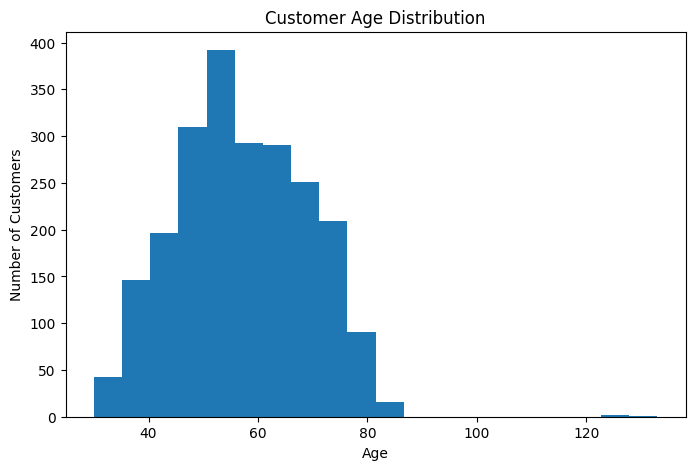

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

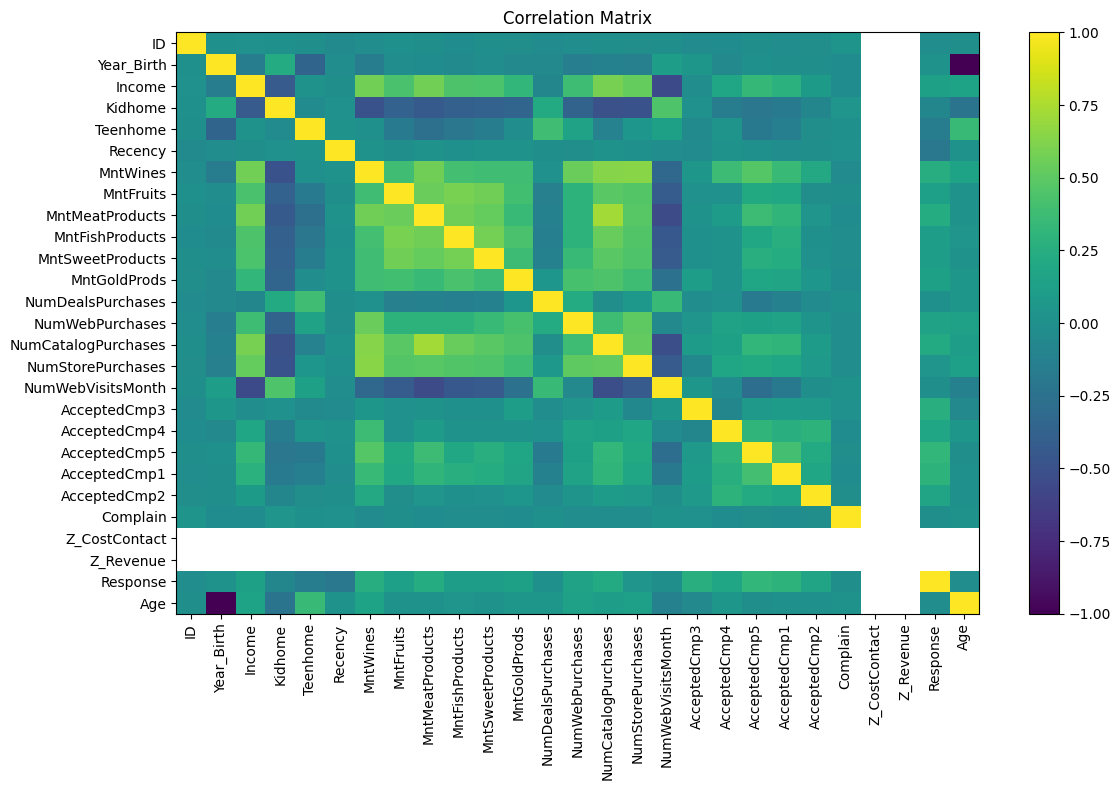

In [18]:
corr = df.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(12,8))
plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

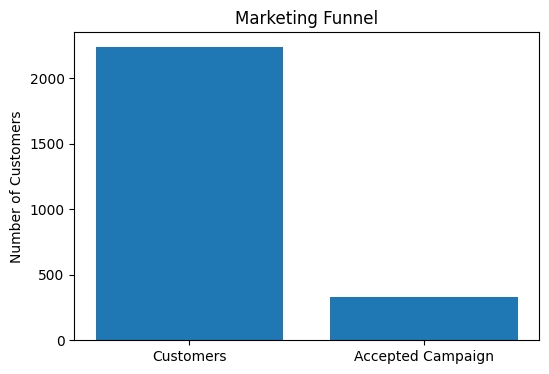

In [19]:
funnel = {
    "Customers": len(df),
    "Accepted Campaign": df["Response"].sum()
}

plt.figure(figsize=(6,4))
plt.bar(funnel.keys(), funnel.values())
plt.title("Marketing Funnel")
plt.ylabel("Number of Customers")
plt.show()

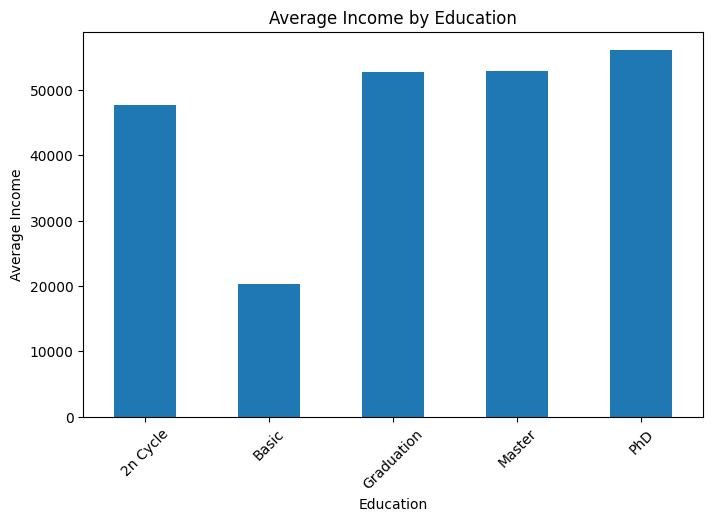

In [20]:
avg_income = df.groupby("Education")["Income"].mean()

plt.figure(figsize=(8,5))
avg_income.plot(kind="bar")
plt.title("Average Income by Education")
plt.xlabel("Education")
plt.ylabel("Average Income")
plt.xticks(rotation=45)
plt.show()